In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('/content/superstore_sales_cleaned.csv')

Question 1: Which region brings in the highest sales and profit?

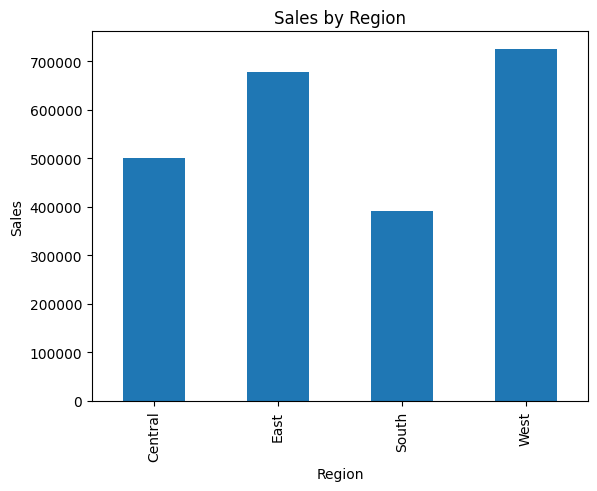

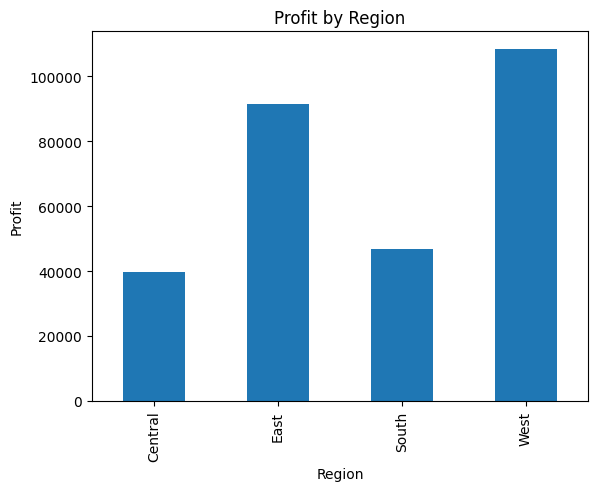

In [24]:
# Sales by Region
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

# Profit by Region
sfo = df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

Question 2: Which category/subcategory drives the most revenue

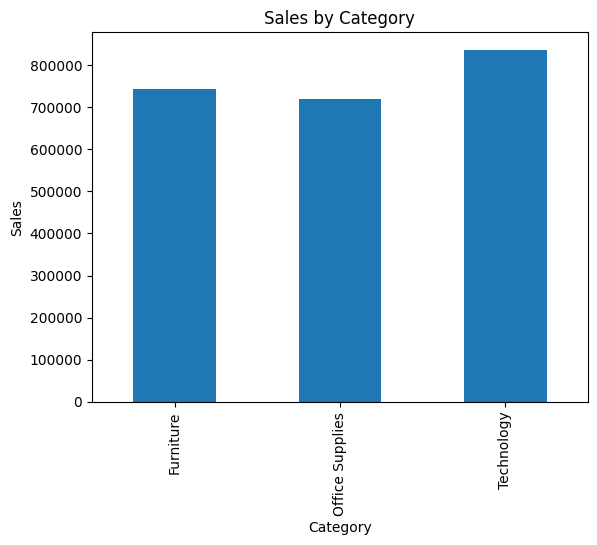

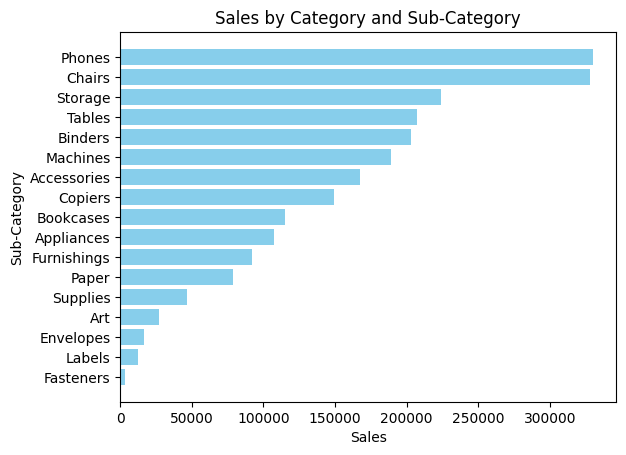

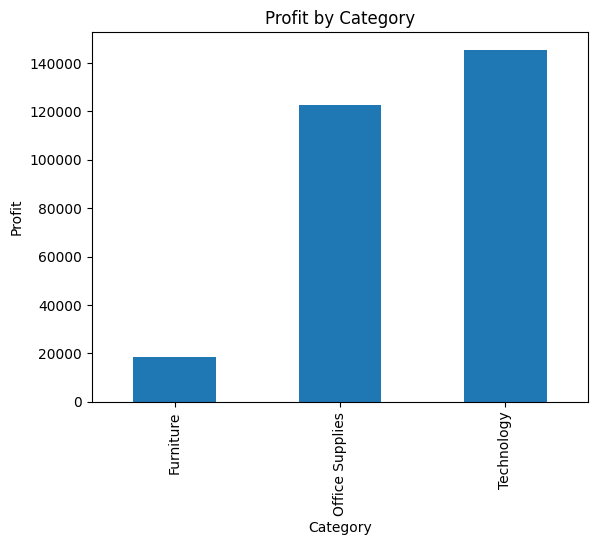

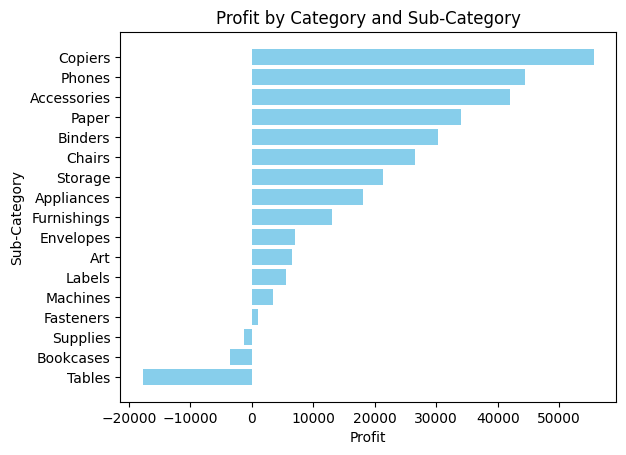

In [25]:
# Sales by Category
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

#Sales by Category and Sub-Category
category_sub_sales = (df.groupby(['Category', 'Sub-Category']) ['Sales']
                      .sum()
                      .reset_index()
                      .sort_values('Sales', ascending = False))

plt.barh(category_sub_sales['Sub-Category'],
         category_sub_sales['Sales'],
         color = 'skyblue')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
plt.title('Sales by Category and Sub-Category')
plt.gca().invert_yaxis()
plt.show()

# Profit by Category
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

# Profit by Category and Sub-Category
category_sub_profit = (df.groupby(['Category', 'Sub-Category']) ['Profit']
                      .sum()
                      .reset_index()
                      .sort_values('Profit', ascending = False))

plt.barh(category_sub_profit['Sub-Category'],
         category_sub_profit['Profit'],
         color = 'skyblue')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.title('Profit by Category and Sub-Category')
plt.gca().invert_yaxis()
plt.show()


Question 3: Which customer segment has the highest profit margin?

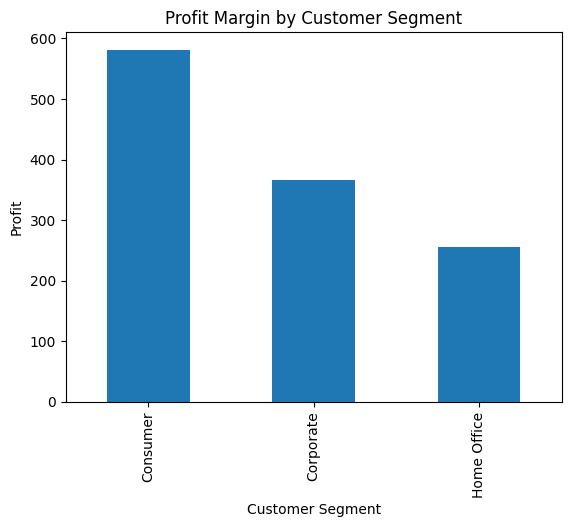

In [26]:
# Proft Margin by Customer Segment
df.groupby('Segment')['Profit Margin'].sum().plot(kind='bar')
plt.title('Profit Margin by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Profit')
plt.show()

Question 4: What are the month sale trends?

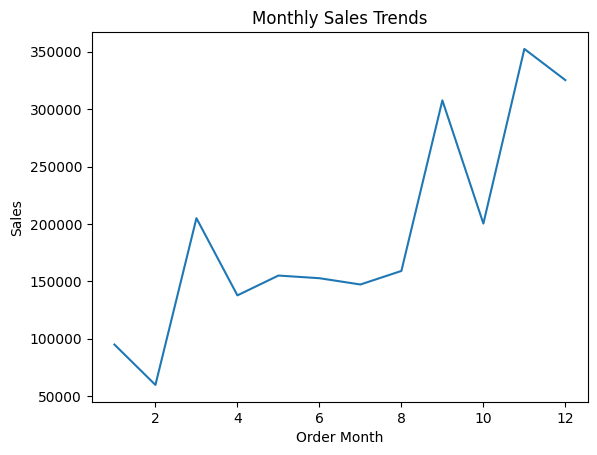

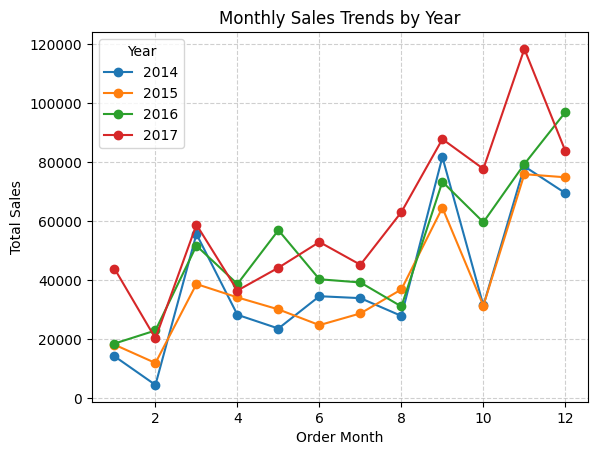

In [27]:
# Monthly Sales Trend
df.groupby('Order Month')['Sales'].sum().plot(kind='line')
plt.title('Monthly Sales Trends')
plt.xlabel('Order Month')
plt.ylabel('Sales')
plt.show()

# Month Sales Trends per Year
monthly_sales_per_year = (df.groupby(['Order Year', 'Order Month'])
                          ['Sales']
                          .sum()
                          .reset_index()
                          .sort_values(['Order Year', 'Order Month']))

# Pivot to ensure each year is its own column
monthly_pivot = monthly_sales_per_year.pivot(index='Order Month',
                                             columns='Order Year',
                                             values='Sales')


# Plot monthly trend for each year
for year in monthly_pivot.columns:
    plt.plot(monthly_pivot.index, monthly_pivot[year], marker='o', label=year)

plt.title('Monthly Sales Trends by Year')
plt.xlabel('Order Month')
plt.ylabel('Total Sales')
plt.legend(title='Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Question 5. How do discounts affect sales and profit margin?

          Discount     Sales    Profit
Discount  1.000000 -0.028190 -0.219487
Sales    -0.028190  1.000000  0.479064
Profit   -0.219487  0.479064  1.000000


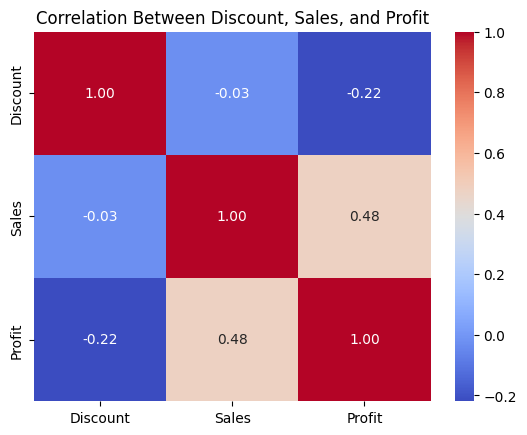

In [28]:
corr = df[['Discount', 'Sales', 'Profit']].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Discount, Sales, and Profit')
plt.show()